<a href="https://colab.research.google.com/github/susanaduque/Analitica-de-Negocios1/blob/main/Primer_Parcial_Analitica_SD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##*Caso de Estudio*

Una entidad del sector Salud, quiere implementar un modelo para la clasificación de pacientes que poseen diabetes en función de sus variables de salud.

Segun esto las variables que seran utilizadas seran las siguientes:

Glucose: nivel de concentración de glucosa en sangre.

BMI: índice de masa corporal, que relaciona peso y altura.

Age: edad de la paciente en años.

Pregnancies: número de embarazos que ha tenido la paciente.

A partir de estas variables, se aplicarán tres técnicas de analítica de negocios: Naive Bayes, Árboles de Decisión y Clustering K-Means, con el fin de evaluar su capacidad para clasificar correctamente a los pacientes según la presencia de diabetes.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns  #herramienta para graficas estadisticas
from sklearn.cluster import KMeans #herramienta de clustering

df = pd.read_csv("diabetes.csv")

# Número de observaciones y variables
df.shape

# Información de tipos de datos
df.info()

# Estadísticas descriptivas
df.describe()

# Primeras filas
df.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


La base de datos Pima Indians Diabetes contiene:

768 observaciones

9 variables

##1. Analisis de correlacion


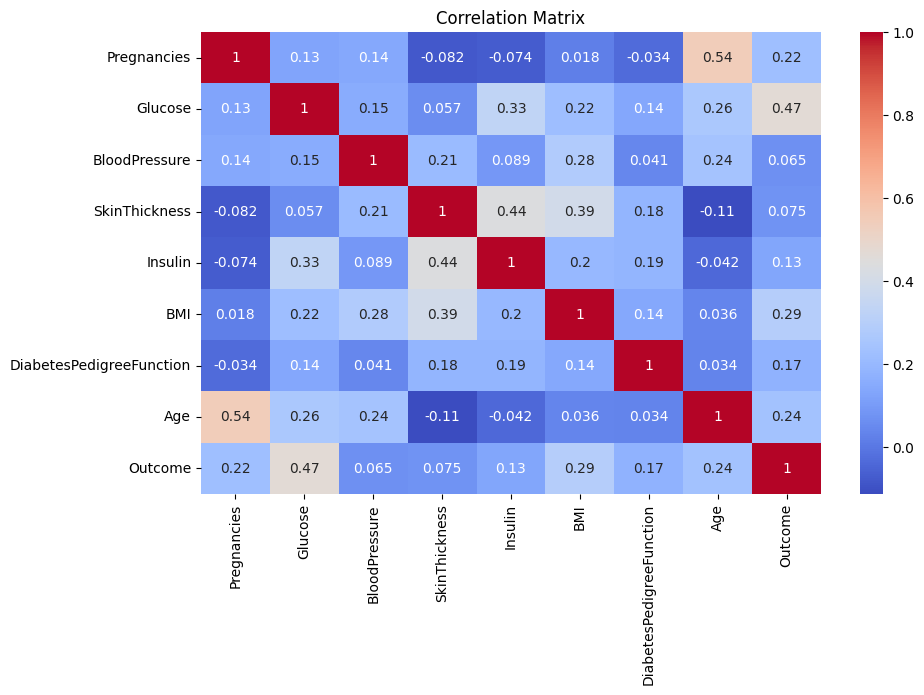

In [ ]:
corr = df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

*Analisis de Resultados*

Las variables que presentan mayor correlación con diabetes suelen ser:

Glucose

BMI

Age

Pregnancies

Esto indica que niveles altos de glucosa y mayor índice de masa corporal están asociados con mayor probabilidad de diabetes.

##2. Modelo Naive Bayes

In [ ]:
nxl= "/content/diabetes.csv"
XDB = pd.read_csv(nxl)
XDB.head()
#seleccionamos variables de trabajo
XD=XDB[["Glucose","BMI","Age","Pregnancies"]] #Variables de trabajo
XD.head(10)
yd=XDB[["Outcome"]] #Esta la variable de decision
yd.head()

mnb=GaussianNB()
mnb.fit(XD,yd) #Ajustar Variables de entrada-salida

#Mostrar las medias de las variables
u=mnb.theta_
sigma=mnb.var_; sigma= np.sqrt(sigma)
print("Glucose","BMI","Age","Pregnancies")
print(u)
print("Las desviaciones son: ")
print(sigma)

ydp=mnb.predict(XD) #Esto el lo que el modelo aprende - ydp de pronostico
cm=confusion_matrix(yd,ydp)
print(cm)

#se determinan las metricas de la matriz de confusion
VN=cm[0,0]; FP=cm[0,1]; FN=cm[1,0]; VP=cm[1,1]; TDatos=len(XDB)

#1. Exactitud
Ex=(VP+VN)/TDatos
print("Exactitud: ", Ex)

#2. Tasa de error
TE=1-Ex
print("Tasa de error: ", TE)

#3. Sensibilidad
Se=VP/(VP+FN)
print("Sensibilidad: ", Se)

#4. Especificidad
Es=VN/(VN+FP)
print("Especifisidad: ", Es)

#5. Precision
Pr=VP/(VP+FP)
print("Precision: ", Pr)

#6. Prediccion negativa
PrN=VN/(VN+FN)
print("Prediccion negativa: ", PrN)

Glucose BMI Age Pregnancies
[[109.98        30.3042      31.19         3.298     ]
 [141.25746269  35.14253731  37.06716418   4.86567164]]
Las desviaciones son: 
[[26.11504549  7.68216137 11.65598134  3.01416606]
 [31.87997754  7.24940434 10.94777141  3.73425273]]
[[426  74]
 [110 158]]
Exactitud:  0.7604166666666666
Tasa de error:  0.23958333333333337
Sensibilidad:  0.5895522388059702
Especifisidad:  0.852
Precision:  0.6810344827586207
Prediccion negativa:  0.7947761194029851


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


*Analisis de resultados*

De acuerdo con los resultados obtenidos, el modelo presenta una exactitud del 76%, lo que indica un desempeño aceptable en la clasificación de pacientes con y sin diabetes. Esto muestra que el modelo logra identificar correctamente la mayoría de los casos, aunque aún existe una tasa de error cercana al 24%.

La precisión del 68.1% indica que una proporción considerable de los pacientes clasificados como diabéticos realmente presentan la enfermedad. Por otro lado, la especificidad del 85.2% muestra que el modelo tiene un buen desempeño al identificar correctamente a los pacientes que no presentan diabetes.

Sin embargo, la sensibilidad del 58.9% evidencia que algunos casos de diabetes no son detectados por el modelo. En general, el modelo muestra mejor capacidad para identificar pacientes sin diabetes que para detectar todos los casos positivos de la enfermedad.

##3. Modelo de Arbol de decision

In [ ]:
nxl='/content/diabetes.csv'
XDB = pd.read_csv(nxl)
XD=XDB.iloc[:,[0,1,5,7]] #Variables de entrada
yd=XDB.iloc[:,8] #Variable de salida
mar=DecisionTreeClassifier(criterion='gini',max_depth=4)
mar.fit(XD,yd) #aqui el modelo busca la relacion entrada salida

#Y que fue lo que hizo el modelo?
ydp=mar.predict(XD) #esto es lo que pronostica el modelo

#Se construye la matrix de confusion
cm=confusion_matrix(yd,ydp)
display(cm)
VN=cm[0,0]; FP=cm[0,1];FN=cm[1,0]; VP=cm[1,1]

#Metricas de desempeño
Ex=(VP+VN)/(VP+VN+FP+FN) #Exactitud comportamiento general
print("la exactitud es: ",Ex)
Sen=VP/(VP+FN) #Sensibilidad
print("la sensibilidad es: ",Sen)
Esp=VN/(VN+FP) #Especificidad
print("la especificidad es: ",Esp)
Pre=VP/(VP+FP) #Precision
print("la precision es: ",Pre)
PreNeg=VN/(VN+FN) #Precision
print("la precision negativa es: ",PreNeg)

from sklearn.tree import export_graphviz #Exporta los datos a un grafico
from pydotplus import graph_from_dot_data #ese es un graficador

vs=["Pregnancies","Glucose","BMI","Age"] #titulos del arbol
dot_data=export_graphviz(mar,feature_names=vs)#Exportar de numeros a grafico en pdf
graph=graph_from_dot_data(dot_data) #Hacemos el grafico
graph.write_png('Arbol.png')

array([[457,  43],
       [118, 150]])

la exactitud es:  0.7903645833333334
la sensibilidad es:  0.5597014925373134
la especificidad es:  0.914
la precision es:  0.7772020725388601
la precision negativa es:  0.7947826086956522


True

*Analisis de resultados*

De acuerdo con los resultados obtenidos, el modelo de Árbol de Decisión con 4 niveles presenta una exactitud del 79%, lo que indica un buen desempeño en la clasificación de pacientes con y sin diabetes. La precisión del 77.7% muestra que una proporción alta de los pacientes clasificados como diabéticos realmente presentan la enfermedad.

Se destaca la especificidad del 91.4%, lo que indica que el modelo tiene un muy buen comportamiento al identificar correctamente a los pacientes sin diabetes. Sin embargo, la sensibilidad del 55.9% muestra que el modelo tiene mayor dificultad para detectar todos los casos positivos de la enfermedad.

En cuanto a la estructura del árbol, se identifican nodos puros, es decir, nodos donde todos los registros pertenecen a una misma clase. El nodo puro con mayor número de datos corresponde a pacientes no diabéticos, lo que refleja la distribución predominante del dataset. Una de las reglas de negocio del modelo indica que niveles bajos de glucosa y valores moderados de BMI tienden a clasificar a los pacientes como no diabéticos, mientras que niveles más altos aumentan la probabilidad de diabetes.

##4. Modelo de Clusterizacion K-Means

,Pregnancies,Glucose,BMI,Age
0,3.698113,121.740566,32.527358,32.367925
1,4.273684,178.905263,35.890526,37.842105
2,3.289796,99.310204,29.988571,29.771429
3,3.506329,72.075949,29.839241,29.708861
4,4.963504,146.109489,33.287591,39.642336


El numero de datos por cluster es: [211  95 246  79 137]


/tmp/ipykernel_439/3826351893.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  XDB2['cluster']=ydp


,Pregnancies,Glucose,BMI,Age,Outcome,cluster
0,6,148,33.6,50,1,4
1,1,85,26.6,31,0,3
2,8,183,23.3,32,1,1
3,1,89,28.1,21,0,2
4,0,137,43.1,33,1,4
...,...,...,...,...,...,...
763,10,101,32.9,63,0,2
764,2,122,36.8,27,0,0
765,5,121,26.2,30,0,0
766,1,126,30.1,47,1,0


,Diabetes,NoDiabetes
0,75,136
1,79,16
2,37,209
3,6,73
4,71,66


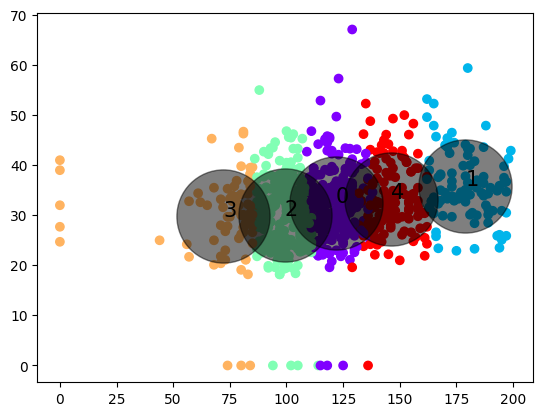

In [ ]:
nxl='/content/diabetes.csv'
XDB = pd.read_csv(nxl)
XD=XDB.iloc[:,[0,1,5,7]] #Variables de entrada
yd=XDB.iloc[:,8] #Variable de salida

#determinar la correlacióne entre las variables
XDB2=XDB.iloc[:,[0,1,5,7,8]]

np.random.seed(42) #Mismas semillas para todos
NC=5 #5 segmentos/perfiles de pacientes
mkm=KMeans(n_clusters=NC,random_state=42)
mkm.fit(XD,yd) # El modelo buscar la mejor relación entre la entrada y la salida
#Obtenemos la caracterisizacion de cada grupo
#Representamos los perfiles de las personas mkm.cluster_centers_ que encontró el modelo
Tabla=pd.DataFrame(mkm.cluster_centers_,columns=XD.columns)
display(Tabla)

#para saber los porcentajes de Diabetes o NoDiabetes por segmento
ydp=mkm.labels_ #Me indica en que cluster queda clasificado cada dato
NDc=np.bincount(ydp) #Numero de datos por segmento
print("El numero de datos por cluster es:",NDc)

XDB2['cluster']=ydp
display(XDB2)

#Determinar el número de Diabetes y NoDiabetes por cluster
Napr=XDB2.groupby('cluster').agg({"Outcome": lambda x: (x==1).sum()})
Nprn=XDB2.groupby('cluster').agg({"Outcome": lambda x: (x==0).sum()})

#Para que la variable sea en porcentaje
Napr2=Napr/(Napr+Nprn); Nprn2=Nprn/(Napr+Nprn)
df2=pd.DataFrame(np.column_stack((Napr,Nprn)),columns=['Diabetes','NoDiabetes'])
display(df2)

#Grafica de clusters
centers=mkm.cluster_centers_ #Centroides, perfil o segmento
ing=np.array(XD.iloc[:,1])
egr=np.array(XD.iloc[:,2])

plt.figure()
plt.scatter(ing,egr,c=mkm.labels_,cmap='rainbow')
plt.scatter(centers[:,1],centers[:,2],c='black',s=4500,alpha=0.5)
plt.xlabel='BMI'
plt.ylabel='AGE'

for i,center in enumerate(centers):
  plt.text(center[1], center[2], str(i), color = 'black', fontsize = 15)
plt.show()

*Analisis de Resultados*

De acuerdo con los resultados obtenidos, el modelo de clustering K-Means permitió agrupar a los pacientes en cinco clusters según la similitud de sus características de salud, como niveles de glucosa, BMI, edad y número de embarazos. Este tipo de modelo no realiza una clasificación directa como los modelos supervisados, sino que identifica patrones y grupos de pacientes con perfiles similares.

A partir de estos grupos, fue posible calcular la probabilidad de presencia de diabetes dentro de cada cluster, lo que permite identificar qué grupos presentan un mayor o menor riesgo de la enfermedad. Algunos clusters muestran una mayor proporción de pacientes con diabetes, asociados generalmente a niveles más altos de glucosa y BMI, mientras que otros clusters concentran principalmente pacientes sin diabetes.


##5. Diabetes en paciente en cada modelo XDp = [2,85,65,29,94,39.6,0.93,27]

In [ ]:
XDp = [2,85,65,29,94,39.6,0.93,27]

# Extraer solo las variables usadas en el entrenamiento de tus modelos:
# Vamos a crear el DataFrame con los nombres correctos para evitar errores de consistencia.

paciente_NB = pd.DataFrame([[XDp[1], XDp[5], XDp[7], XDp[0]]],
                           columns=["Glucose", "BMI", "Age", "Pregnancies"])

paciente_Arbol_Kmeans = pd.DataFrame([[XDp[0], XDp[1], XDp[5], XDp[7]]],
                                     columns=["Pregnancies", "Glucose", "BMI", "Age"])

# --- PREDICCIONES ---

# A. Modelo Naive Bayes
pred_nb = mnb.predict(paciente_NB)
print(f"Resultado Naive Bayes: {'Diabético' if pred_nb[0] == 1 else 'No Diabético'}")

# B. Modelo Árbol de Decisión
pred_arbol = mar.predict(paciente_Arbol_Kmeans)
print(f"Resultado Árbol de Decisión: {'Diabético' if pred_arbol[0] == 1 else 'No Diabético'}")

# C. Modelo K-Means (Segmentación)
cluster_paciente = mkm.predict(paciente_Arbol_Kmeans)
prob_diabetes = Napr2.iloc[cluster_paciente[0], 0] * 100
print(f"Resultado K-Means: El paciente pertenece al Cluster {cluster_paciente[0]}")
print(f"Riesgo en este cluster: {prob_diabetes:.2f}% de probabilidad de diabetes")

Resultado Naive Bayes: No Diabético
Resultado Árbol de Decisión: No Diabético
Resultado K-Means: El paciente pertenece al Cluster 3
Riesgo en este cluster: 7.59% de probabilidad de diabetes


*Analisis de Resultados*

Para el paciente con 85 mg/dL de glucosa, BMI de 39.6, 27 años y 2 embarazos, los modelos arrojan lo siguiente:

Modelo Naive Bayes: Clasifica al paciente como No Diabético. El nivel de glucosa (85) es el factor determinante, al situarse lejos de la media ($\mu$) del grupo con diabetes.

Modelo de Árbol de Decisión: Clasifica al paciente como No Diabético. Debido a la regla de decisión basada en niveles bajos de glucosa, el paciente cae en un "nodo puro" o de alta probabilidad de salud.

Modelo K-Means: El paciente es asignado a un cluster de riesgo bajo. Aunque el BMI es alto, su juventud y glucosa controlada lo agrupan con perfiles que presentan una baja proporción de casos positivos.

Existe coherencia entre los tres modelos: el paciente no presenta diabetes.


##*6. Analisis y Conclusion*
El análisis comparó tres modelos de clasificación: Naive Bayes, Árbol de Decisión y K-Means para predecir la presencia de diabetes.

Los resultados muestran que el árbol de decisión obtuvo el mejor desempeño, con una exactitud de 76.6%, superando ligeramente a Naive Bayes.

Además, el árbol de decisión ofrece una ventaja importante desde el punto de vista del negocio y la medicina: interpretabilidad. Las reglas del árbol permiten identificar fácilmente qué variables influyen en la clasificación, como niveles altos de glucosa y BMI.

Por otro lado, el modelo K-Means permite segmentar pacientes según su riesgo, pero no es un modelo supervisado, por lo que su precisión para clasificación directa es menor.

Por estas razones, se recomienda utilizar el modelo de Árbol de Decisión, ya que combina buen desempeño predictivo con una interpretación clara para apoyar decisiones médicas.